### Bulk RNA-seq Deconvolution with Geneformer Embeddings
This tutorial covers end-to-end bulk RNA-seq deconvolution in DECONVersation using Geneformer embeddings. It walks through extracting embeddings from bulk and single-cell reference data, building signature matrices, and estimating cell type proportions with all solvers available in DECONVersation. Performance is assessed against ground truth using RMSE and Pearson correlation. While this tutorial uses Geneformer, the workflow is fully compatible with Cell2Sentence, CellHermes and scGPT. <br>

#### Import Libraries

In [1]:
import sys
import os
import pandas as pd
import numpy as  np
import scanpy as sc
import deconversation
deconversation.__file__
from deconversation import embeddings, preprocessing, deconvolution, visualization, evaluation

/nfs/home/aoku/.local/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


geneformer successfully imported.
cell2sentence is not installed. Skipping related functions.
cellhermes is not installed. Skipping related functions.
scGPT is not installed. Skipping related functions.
scVI successfully imported.


In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import matplotlib.pyplot as plt
plt.rcParams['axes.grid'] = False
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = 'black'

#### Step 1: Load data

Here we use a PBMC bulk RNAseq dataset from [Hoek et al](https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0118528). Geneformer requires Ensembl IDs, so we mapped our gene symbols back to Ensembl IDs using DECONVersation's `preprocessing.gene_id_name_map()`, which supports conversion in both directions (gene symbols → Ensembl IDs and Ensembl IDs → gene symbols).

We load the reference dataset from [Hao et al.](https://pubmed.ncbi.nlm.nih.gov/34062119/) Again, since Geneformer requires Ensembl IDs, we ensure that `adata.var.index` holds Ensembl IDs rather than gene symbols.

Ground-truth data comes from Hoek et al. (see above). There is a slight mismatch between the ground-truth labels and the cell types available in the reference, so we define a function to match cell types between the two datasets.

In [4]:
# Read in bulk RNAseq data
hoek_bulk = pd.read_csv("/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/deconvBench/bulk/hoek/hoek_counts.csv", index_col=0)

# Geneformer requires ensembl ids, DECONVersation supports mapping gene  names to ids 
hoek_bulk.index = preprocessing.gene_id_name_map(gene_list=hoek_bulk.index, mode="to_ensembl" ) 
hoek_bulk = hoek_bulk.loc[hoek_bulk.index.dropna()] # Drop unmapped genes

# Inspect bulk data
hoek_bulk.iloc[0:4, 0:4].head()

,HD30_PBMC_0,HD30_PBMC_1,HD30_PBMC_3,HD30_PBMC_7
ENSG00000259429,8,2,10,18
ENSG00000215529,35,35,30,26
ENSG00000231649,0,0,0,0
ENSG00000253542,0,0,0,0


In [5]:
# Load scRNA-seq reference data 
path_ref = "/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/deconvBench/geneformer/complete/haoSub.h5ad"
adata = sc.read_h5ad(path_ref)
adata = adata[adata.obs["broad_type"].isin(['B cells', 'Monocytes', 'NK cells', 'T cells', 'mDC', 'pDC'])]

# Ensure adata.var are ensembl ids (required for geneformer) - switch to gene names for scGPT. cellHermes and C2S
adata.var.index = adata.var.gene_id
adata = adata[:, adata.var.index.notnull()] 

In [6]:
# load ground truth data
ground_truth = pd.read_csv("/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/deconvBench/bulk/hoek/hoek_facs.csv", index_col=0)
ground_truth = ground_truth.T

# Inspect data
ground_truth.iloc[0:4, 0:4].head()

,T cell,Monocytes,B cells,mDC
HD30_PBMC_0,0.514,0.155,0.043,0.0264
HD30_PBMC_1,0.457,0.214,0.048,0.0251
HD30_PBMC_3,0.580,0.153,0.042,0.0172
HD30_PBMC_7,0.578,0.135,0.066,0.0184


#### Step 2: Create signature matrix using scRNA reference data

Here we use DECONVersation's `preprocessing.create_signature_matrix()` to build a signature matrix. This averages gene expression across cell types, producing a gene-by-cell-type table covering every unique cell type in the reference dataset.

In [7]:
sig_mat = preprocessing.create_signature_matrix(adata = adata,
                                  sample_col = "batch", # batch or donor id column
                                  cell_type_col = "broad_type", # cell type column to average 
                                  groupby = "broad_type",
                                  output_path = None)

# Transpose for embedding extraction
sig_mat = sig_mat.T

# Inspect signature matrix
sig_mat.iloc[0:4, 0:4].head()

gene_id,ENSG00000121410,ENSG00000268895,ENSG00000148584,ENSG00000175899
broad_type,,,,
B cells,0.217336,0.031785,0.000449,0.001496
Monocytes,0.349243,0.037201,0.000062,0.002642
NK cells,0.086643,0.009497,0.000167,0.009497
T cells,0.267866,0.019023,0.000210,0.009827


#### Step 3: Extract geneformer embeddings on signature matrix and bulk data

Here we extract Geneformer embeddings from both the signature matrix and the bulk RNA-seq dataset (Hoek et al.) using Geneformer's zero-shot model from `ctheodoris/Geneformer`. Embedding extraction writes intermediate files, such as the tokenized dataset. We set `delete_temp_files=True` so these are removed automatically once extraction finishes. Set it to `False` if you want to keep them.

In [8]:
# Extract geneformer embeddings on signature matrix
sig_mat_gf = embeddings.extract_embs(
    bulk_df = sig_mat,
    mode = "geneformer",
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "ctheodoris/Geneformer",
    delete_temp_files = True
)

Bulk AnnData saved to: /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad
Starting Geneformer tokenization...
Tokenizing /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  6.18it/s]


/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad has no column attribute 'filter_pass'; tokenizing all cells.
Creating dataset.
Loading Geneformer model...


CLS token present in token dictionary, excluding from average.
EOS token present in token dictionary, excluding from average.


Loading tokenized dataset...
Extracting Geneformer embeddings...


  0%|          | 0/1 [00:00<?, ?it/s]

In [9]:
# Extract geneformer embeddings on bulk data
bulk_gf = embeddings.extract_embs(
    bulk_df = hoek_bulk.T, # sample x ensembl id
    mode = "geneformer",
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "ctheodoris/Geneformer",  # Default geneformer model
    delete_temp_files = True # if True, delete all temporary files created whiile extracting embeddings
)

Bulk AnnData saved to: /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad
Starting Geneformer tokenization...
Tokenizing /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 35.23it/s]


/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad has no column attribute 'filter_pass'; tokenizing all cells.
Creating dataset.
Loading Geneformer model...


CLS token present in token dictionary, excluding from average.
EOS token present in token dictionary, excluding from average.


Loading tokenized dataset...
Extracting Geneformer embeddings...


  0%|          | 0/1 [00:00<?, ?it/s]

#### Step 3:  Run deconvolution

Here we run deconvolution with `deconvolution.run_deconv()`, which uses NNLS by default. A different solver can be passed instead, or `deconvolution.run_all_deconv()` can be used to run every solver available in DECONVersation at once.
We then plot predicted against true proportions with `visualization.plot_true_vs_predicted()`. We set `stratify_by_celltype=False` to show all cell types on a single scatter plot; set it to `True` to get a separate plot per cell type.

In [10]:
# Run deconvolution
result = deconvolution.run_deconv(bulk_df = bulk_gf.T, 
                                  signature_df = sig_mat_gf.T)

# Harmonize results to match ground truth
def harmonize_columns(df):
    df = df.copy()
    if "pDC" in df.columns and "mDC" in df.columns:
        df["mDC"] = df["mDC"] + df["pDC"]
        df = df.drop(columns=["pDC"])
    elif "pDC" in df.columns:       
        df = df.rename(columns={"pDC": "mDC"})
    df = df.rename(columns={"T cells": "T cell"})
    return df

# Harmonize results to match ground truth
result = harmonize_columns(result)

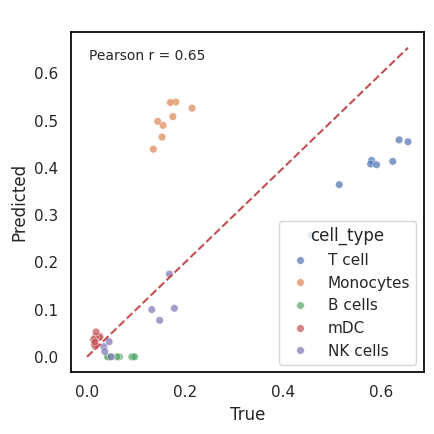

In [11]:
visualization.plot_true_vs_predicted(y_true_df=ground_truth, 
                                     y_pred_df=result, 
                                     stratify_by_celltype=False, 
                                     dot_size=30)

#### Step 4: Visualize results

After running `deconvolution.run_all_deconv()`, the results can be visualized with `visualization.visualize_solvers()`, which plots correlation and RMSE across all solvers used. Setting `level="cell_type"` reports correlation and RMSE per cell type instead.

#### Compare with PCA

Here we re-run the same analyses with PCA for comparison. We use `embeddings.extract_components()` to compute PCA embeddings, fitting on the signature matrix and applying the transform to the bulk data. This caps the number of components at the total number of cell types present in the signature matrix.

In [12]:
# Extract principal components frm bulk data and signature matrix 
# Fit on signature matrix and apply on  bulk
sig_mat_bulk_pca = embeddings.extract_components(bulk_df = hoek_bulk.T,
                                                 sig_mat = sig_mat,
                                                 mode = "pca",
                                                 transform = True)

bulk_pca = sig_mat_bulk_pca["pca_bulk"]
sig_mat_pca = sig_mat_bulk_pca["sig_pca"]

Variance explained by 6 PCs: 100.00%


In [13]:
# Run deconvolution
results_pca = deconvolution.run_deconv(bulk_df = bulk_pca.T, 
                                  signature_df = sig_mat_pca.T)

results_pca = harmonize_columns(results_pca)

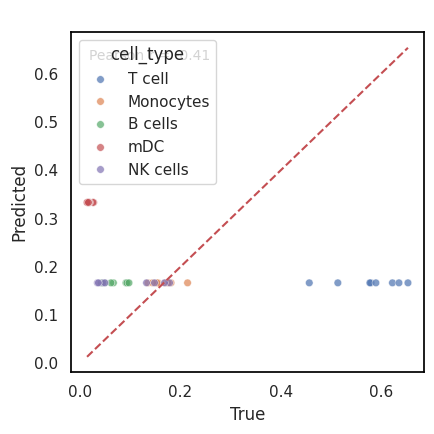

In [22]:
# Visualize results (PCA)
visualization.plot_true_vs_predicted(y_true_df=ground_truth, 
                                     y_pred_df=results_pca, 
                                     stratify_by_celltype=False, 
                                     dot_size=30)

#### Alternative Approach Using core.py

Embeddings can also be extracted directly via DECONVersation's core functions. Rather than pre-computing embeddings separately, bulk RNA-seq and single-cell reference data (h5ad format) are passed directly to ```deconversation.deconverse()```, along with cell type and sample/donor annotations when single-cell data is provided. This  approach is compatible with all models supported by DECONVersation, including Geneformer, scGPT, Cell2Sentence, CellHermes, scVI, and PCA. <br>

In [15]:
res = deconversation.deconverse(
    bulk_df = "/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/deconvBench/bulk/hoek/hoek_counts.csv",
    adata = "/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/deconvBench/geneformer/complete/haoSub.h5ad",
    model = "ctheodoris/Geneformer",
    mode = "geneformer",
    cell_type_col = "broad_type",
    sample_col = "batch",
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/tempgf/")

Using model: geneformer
Bulk data rows are not ENSG ids, converting...
Extracting signature embedding...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  6.02it/s]


  0%|          | 0/1 [00:00<?, ?it/s]

Extracting bulk embedding...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 34.19it/s]


  0%|          | 0/1 [00:00<?, ?it/s]

Solving deconvolution...


In [16]:
# Harmonize results to match ground truth
results = harmonize_columns(res)

# Inspect results:
results.head()

broad_type,B cells,Monocytes,NK cells,Platelet,T cell,mDC
HD30_PBMC_0,0.0,0.364570,0.040373,0.309813,0.275984,0.009259
HD30_PBMC_1,0.0,0.399857,0.111210,0.310578,0.171286,0.007068
HD30_PBMC_3,0.0,0.337491,0.014011,0.316831,0.324410,0.007257
HD30_PBMC_7,0.0,0.308938,0.034612,0.325392,0.314413,0.016646
HD31_PBMC_0,0.0,0.401556,0.000000,0.314202,0.284242,0.000000


In [17]:
ground_truth.head()

,T cell,Monocytes,B cells,mDC,NK cells
HD30_PBMC_0,0.514,0.155,0.043,0.0264,0.178
HD30_PBMC_1,0.457,0.214,0.048,0.0251,0.168
HD30_PBMC_3,0.580,0.153,0.042,0.0172,0.148
HD30_PBMC_7,0.578,0.135,0.066,0.0184,0.132
HD31_PBMC_0,0.590,0.181,0.091,0.0163,0.045


In [18]:
evaluation.compute_correlation(true_df=ground_truth, pred_df=results)

np.float64(0.6441903227837804)

In [19]:
evaluation.compute_rmse(true_df=ground_truth, pred_df=results)

np.float64(0.16756961607937954)

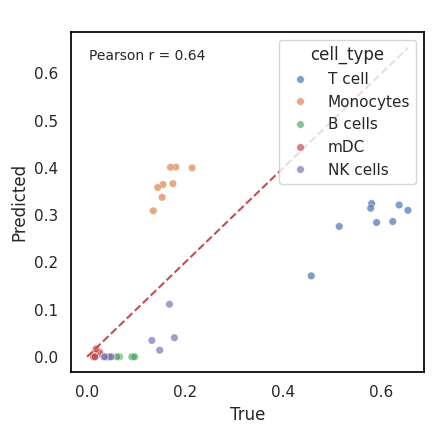

In [21]:
visualization.plot_true_vs_predicted(y_true_df=ground_truth, 
                                     y_pred_df=results, 
                                     stratify_by_celltype=False,
                                    dot_size=30)